In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
import csv
from scipy.ndimage import label
import math
%matplotlib inline
import matplotlib as mpl
from scipy.constants import Avogadro

In [6]:
plt.rcParams.update({
    'font.size': 8,
    'axes.labelsize': 8,
    'axes.titlesize': 8,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 6,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'font.family': 'sans-serif',
})

hexcolors = [
    '#D1B8D7', '#AE76A3', '#882E72',
    '#1965B0', '#5289C7', '#7BAFDE',
    '#4EB265', '#90C987', '#CAE0AB',
    '#F7F056', '#F6C141', '#F1932D',
    '#E8601C', '#DC050C', '#777777',
    '#000000'
]
 
colornames = [
    'purple1','purple2','purple3',
    'blue1','blue2','blue3',
    'green1','green2','green3',
    'yellow1','yellow2','orange1',
    'orange2','red','grey', 'black'
]
 
rnb_colors = dict(zip(colornames, hexcolors))

rnb_cmap = ListedColormap(hexcolors, name="rnb")

rnb_cmap_cont = LinearSegmentedColormap.from_list(
    "rnb_continuous",
    hexcolors[::-1],
    N=256  # smoothness
)

## Figure 4B

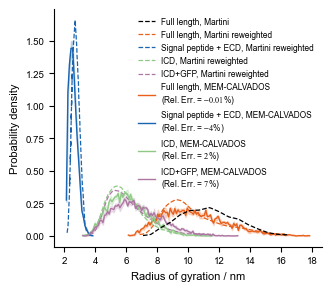

In [7]:
bin_width = 0.1

# Reference Values
martini_rg = {'FL': 10.36, 'ECD': 2.7, 'ICD': 6.0, 'ICD_GFP': 6.2}

memcal_mean = {}
memcal_rg_combined = {}

for domain in martini_rg.keys():
    all_rg = []
    for i in range(5):
        data = np.load(f'data/GHR/GHR_{i}_domain_rgs.npy', allow_pickle=True).item()
        all_rg.append(data[domain][:])
    memcal_rg_combined[domain] = np.concatenate(all_rg)
    memcal_mean[domain] = np.mean(memcal_rg_combined[domain])

rel_error = {k: 100 * (memcal_mean[k] - martini_rg[k]) / martini_rg[k] for k in martini_rg.keys()}

fig, ax = plt.subplots(figsize=(3.2, 2.8), constrained_layout=True)

legends = [
    ('FL', 'orange2', 'Full length, '),
    ('ECD', 'blue1', 'Signal peptide + ECD, '),
    ('ICD', 'green2', 'ICD, '),
    ('ICD_GFP', 'purple2', 'ICD+GFP, ')]

x, h = np.loadtxt(f'data/GHR/martini_rg_FL_norew.csv', unpack=True)
ax.plot(x, h, color='k', ls='--', lw=0.9, zorder=100, label='Full length, Martini')

for filename, color, label_prefix in legends:
    x, h = np.loadtxt(f'data/GHR/martini_rg_{filename}.csv', unpack=True)
    ax.plot(x, h, color=rnb_colors[color], ls='--', lw=0.9, 
            label=f'{label_prefix}Martini reweighted')


for domain, color, label_prefix in legends:
    rg = memcal_rg_combined[domain]
    bins = np.arange(rg.min(), rg.max() + bin_width, bin_width)
    histograms = []
    for i in range(5):
        data = np.load(f'data/GHR/GHR_{i}_domain_rgs.npy', allow_pickle=True).item()
        rg_replica = data[domain][:]
        h, _ = np.histogram(rg_replica, bins=bins, density=True)
        histograms.append(h)
    
    x = bins[:-1] + bin_width / 2.0
    h_mean = np.mean(histograms, axis=0)
    h_sem = np.std(histograms, axis=0) / np.sqrt(5)
    
    if domain=='FL':
        lbl = f"{label_prefix}MEM-CALVADOS\n(Rel. Err. = ${rel_error[domain]:.2f}$%)"
    else:
        lbl = f"{label_prefix}MEM-CALVADOS\n(Rel. Err. = ${rel_error[domain]:.0f}$%)"
    ax.plot(x, h_mean, color=rnb_colors[color], lw=1, label=lbl)
    ax.fill_between(x, h_mean - h_sem, h_mean + h_sem, color=rnb_colors[color], alpha=0.2)

ax.set_xlabel('Radius of gyration / nm')
ax.set_ylabel('Probability density')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.legend(frameon=False, handlelength=2, ncols=1)
plt.show()

## Figures 4C,D

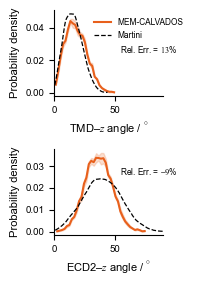

In [12]:
all_tmd = []
all_d2 = []
for i in range(5):
    data = np.load(f'data/GHR/GHR_{i}_domain_angles.npy', allow_pickle=True).item()
    all_tmd.append(data['TMD'][:,0])
    all_d2.append(data['D2'][:,0])
all_tmd = np.concatenate(all_tmd)
error_tmd = 100 * (np.mean(all_tmd) - 16) / 16
all_d2 = np.concatenate(all_d2)
error_d2 = 100 * (np.mean(d2) - 40) / 40

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(1.8, 2.9), sharey=False)

bin_width = 2
bins_tmd = np.arange(all_tmd.min(), all_tmd.max() + bin_width, bin_width)
x_tmd = bins_tmd[:-1] + bin_width / 2.0
h_tmd = np.histogram(all_tmd, bins=bins_tmd, density=True)[0]
histograms = []
for i in range(5):
    data = np.load(f'data/GHR/GHR_{i}_domain_angles.npy', allow_pickle=True).item()
    h, _ = np.histogram(data['TMD'][:,0], bins=bins_tmd, density=True)
    histograms.append(h)
h_sem_tmd = np.std(histograms, axis=0) / np.sqrt(5)

ax1.plot(x_tmd, h_tmd, color=rnb_colors['orange2'], label='MEM-CALVADOS')
ax1.fill_between(x_tmd, h_tmd - h_sem_tmd, h_tmd + h_sem_tmd, color=rnb_colors['orange2'], alpha=0.2)

c, d = np.loadtxt('data/GHR/martini_tmd_tilt.csv', unpack=True)
ax1.plot(c, d, color='k', ls='--', label='Martini', lw=0.9)

ax1.set_xlim(0, 90)
ax1.set_ylabel('Probability density')
ax1.set_xlabel(r'TMD–$z$ angle / $^{\circ}$')
ax1.spines['right'].set_visible(False)
ax1.spines['top'].set_visible(False)
ax1.legend(frameon=False, loc='upper left', bbox_to_anchor=(0.3, 1.0))
ax1.text(0.6, 0.5, f'Rel. Err. = ${error_tmd:.0f}$%', transform=ax1.transAxes, fontsize=6)

bins_d2 = np.arange(all_d2.min(), all_d2.max() + bin_width, bin_width)
x_d2 = bins_d2[:-1] + bin_width / 2.0
h_d2 = np.histogram(all_d2, bins=bins_d2, density=True)[0]
histograms = []
for i in range(5):
    data = np.load(f'data/GHR/GHR_{i}_domain_angles.npy', allow_pickle=True).item()
    h, _ = np.histogram(data['D2'][:,0], bins=bins_d2, density=True)
    histograms.append(h)
h_sem_d2 = np.std(histograms, axis=0) / np.sqrt(5)

ax2.plot(x_d2, h_d2, color=rnb_colors['orange2'], label='MEM-CALVADOS')
ax2.fill_between(x_d2, h_d2 - h_sem_d2, h_d2 + h_sem_d2, color=rnb_colors['orange2'], alpha=0.2)

e, f = np.loadtxt('data/GHR/martini_d2.csv', unpack=True)
ax2.plot(e, f, color='k', ls='--', label='Martini', lw=0.9)

ax2.set_xlim(0, 90)
ax2.set_ylabel('Probability density')
ax2.set_xlabel(r'ECD2–$z$ angle / $^{\circ}$')
ax2.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.text(0.6, 0.7, f'Rel. Err. = ${error_d2:.0f}$%', transform=ax2.transAxes, fontsize=6)

plt.tight_layout()
plt.show()

## Figure S18

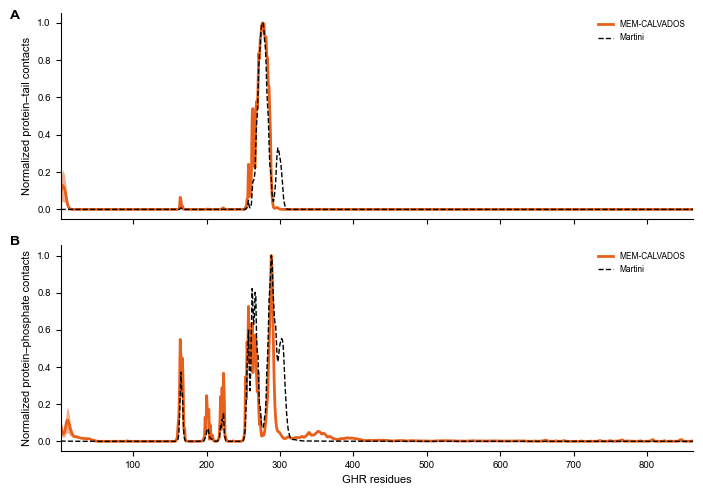

In [13]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True, sharey=False)
plt.rc('font', **{'family':'sans-serif','sans-serif':['Arial'], 'size': 8})

contacts = np.array([
    np.load(f'data/GHR/GHR_{i}_protein_tail_cprofile.npy')
    for i in range(5)])
mean_contacts = contacts.mean(axis=0)
std_contacts = contacts.std(axis=0) 
std_contacts /= mean_contacts.max()
mean_contacts /= mean_contacts.max()
residues = np.arange(1, mean_contacts.size + 1)
ax1.plot(residues,mean_contacts,color=rnb_colors['orange2'],linewidth=2,label='MEM-CALVADOS')
ax1.fill_between(residues,mean_contacts - std_contacts,mean_contacts + std_contacts,
                 color=rnb_colors['orange2'],alpha=0.5,linewidth=0)

contacts = np.load(f'data/GHR/Martini_protein_tail_cprofile.npy')
contacts /= contacts.max()
residues = np.arange(1, contacts.size + 1)
ax1.plot(residues,contacts,color='k',linewidth=1,ls='--',label='Martini')

#######

contacts = np.array([
    np.load(f'data/GHR/GHR_{i}_protein_pho_cprofile.npy')
    for i in range(5)])
mean_contacts = contacts.mean(axis=0)
std_contacts = contacts.std(axis=0) 
std_contacts /= mean_contacts.max()
mean_contacts /= mean_contacts.max()
residues = np.arange(1, mean_contacts.size + 1)
ax2.plot(residues,mean_contacts,color=rnb_colors['orange2'],linewidth=2,label='MEM-CALVADOS')
ax2.fill_between(residues,mean_contacts - std_contacts,mean_contacts + std_contacts,
                 color=rnb_colors['orange2'],alpha=0.5,linewidth=0)

contacts = np.load(f'data/GHR/Martini_protein_pho_cprofile.npy')
contacts /= contacts.max()
residues = np.arange(1, contacts.size + 1)
ax2.plot(residues,contacts,color='k',linewidth=1,ls='--',label='Martini')

ax2.set_xlabel('GHR residues')
ax1.set_ylabel('Normalized protein–tail contacts')
ax2.set_ylabel('Normalized protein–phosphate contacts')
ax1.legend(frameon=False,handlelength=1.8)
ax2.legend(frameon=False,handlelength=1.8)
ax1.set_xlim(1,mean_contacts.size)
ax2.set_xlim(1,mean_contacts.size)
ax1.annotate('A',(-.08,.97),xycoords='axes fraction',fontsize=10,weight='bold')
ax2.annotate('B',(-.08,1),xycoords='axes fraction',fontsize=10,weight='bold')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
#plt.savefig('figS18.pdf')
plt.show()

## Figure S19

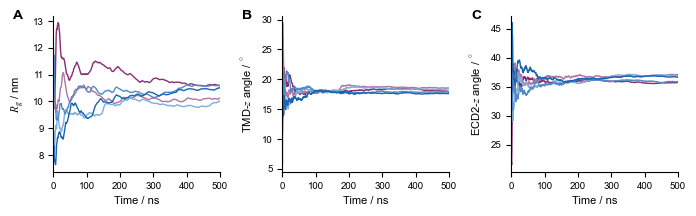

In [14]:
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial'], 'size': 8})

replica_colors = [rnb_colors[c] for c in ['purple3', 'purple2', 'blue3', 'blue2', 'blue1']]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.2), sharex=True)
configs = [('rgs', 'FL', r'$R_g$ / nm'), ('angles', 'TMD', r'TMD-$z$ angle / ${^\circ}$'), ('angles', 'D2', r'ECD2-$z$ angle / ${^\circ}$')]

for ax, (kind, key, ylabel), label in zip(axes, configs, 'ABC'):
    for i, color in enumerate(replica_colors):
        data = np.load(f'data/GHR/GHR_{i}_domain_{kind}.npy', allow_pickle=True).item()
        y = data[key] if kind == 'rgs' else data[key][:, 0]
        time = 0.5 * np.arange(1, y.size + 1)
        ax.plot(time, np.cumsum(y) / np.arange(1, y.size + 1), color=color, lw=1)

    ax.set_xlabel('Time / ns')
    ax.set_ylabel(ylabel)
    ax.annotate(label, (-0.24, .98), xycoords='axes fraction', fontsize=10, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.xlim(0,500)
plt.tight_layout()
#plt.savefig('figS19.pdf')
plt.show()